In [111]:
import json
import os
import random
import re
import numpy as np
from sklearn.model_selection import train_test_split

def clean_text(text):
    """Заменяем переносы строк и табуляции на пробелы"""
    if isinstance(text, str):
        text = re.sub(r'\n|\r|\t', ' ', text)
        text = re.sub(r'\s+', ' ', text)
        return text.strip()
    return text

def load_json_texts(filepath, source_type):
    """
    Загружает тексты из JSON файла по значению поля 'source'
    source_type: 'human', 'ai', 'ai+rew' (paraphrased)
    """
    with open(filepath, 'r', encoding='utf-8') as f:
        data = json.load(f)
    
    texts = []
    for item in data:
        if item.get('source') == source_type:
            text = clean_text(item.get('text', ''))
            if len(text.split()) >= 50:
                texts.append(text)
    return texts

# Параметры первого файла
base_path = 'ru_hard_dataset'
domain = 'news'  # или 'news', 'scientific_texts', 'long_sc'

# Загружаем human и ai
human_file = os.path.join(base_path, domain, 'original_news.json')
ai_file = os.path.join(base_path, domain, 'generated_news.json')

human_texts = load_json_texts(human_file, 'human')
ai_texts = load_json_texts(ai_file, 'ai')

print(f"Первый файл ({domain}) - после фильтрации по длине:")
print(f"  Human: {len(human_texts)} текстов")
print(f"  AI: {len(ai_texts)} текстов")

# Балансировка
n_samples = min(len(human_texts), len(ai_texts))
print(f"\nБалансировка: берем {n_samples} текстов каждого класса")

if len(human_texts) > n_samples:
    human_texts = random.sample(human_texts, n_samples)
if len(ai_texts) > n_samples:
    ai_texts = random.sample(ai_texts, n_samples)

# Разделение 80/20 (80% обучение, 20% валидация)
human_train, human_val = train_test_split(human_texts, test_size=0.2, random_state=42, shuffle=True)
ai_train, ai_val = train_test_split(ai_texts, test_size=0.2, random_state=42, shuffle=True)

print(f"\nРазделение 80/20:")
print(f"  Обучение: human={len(human_train)}, ai={len(ai_train)}")
print(f"  Валидация: human={len(human_val)}, ai={len(ai_val)}")

# Сохраняем файлы обучения
with open('train_texts.txt', 'w', encoding='utf-8') as f:
    for text in human_train + ai_train:
        f.write(clean_text(text) + '\n')

# Сохраняем валидационные файлы
with open('val_human.txt', 'w', encoding='utf-8') as f:
    for text in human_val:
        f.write(clean_text(text) + '\n')

with open('val_ai.txt', 'w', encoding='utf-8') as f:
    for text in ai_val:
        f.write(clean_text(text) + '\n')

print("\nСохранено:")
print(f"  train_texts.txt: {len(human_train)+len(ai_train)} текстов")
print(f"  val_human.txt: {len(human_val)} текстов")
print(f"  val_ai.txt: {len(ai_val)} текстов")

# Запоминаем размер валидационной выборки для второго файла
val_size = len(human_val)
print(f"\nРазмер валидационной выборки: {val_size} текстов каждого класса")

Первый файл (news) - после фильтрации по длине:
  Human: 480 текстов
  AI: 480 текстов

Балансировка: берем 480 текстов каждого класса

Разделение 80/20:
  Обучение: human=384, ai=384
  Валидация: human=96, ai=96

Сохранено:
  train_texts.txt: 768 текстов
  val_human.txt: 96 текстов
  val_ai.txt: 96 текстов

Размер валидационной выборки: 96 текстов каждого класса


In [112]:
import os
import subprocess

bin_path = os.path.abspath("kenlm-master/build/bin")
lmplz_path = os.path.join(bin_path, "lmplz")
build_binary_path = os.path.join(bin_path, "build_binary")

print("Обучение KenLM модели...")

!{lmplz_path} -o 3 < train_texts.txt > model.arpa
!{build_binary_path} model.arpa model.binary

!ls -lh model.arpa model.binary

import kenlm
model = kenlm.Model('model.binary')
print("Модель успешно загружена!")

Обучение KenLM модели...
=== 1/5 Counting and sorting n-grams ===
Reading /workspace/cloud/experiments/train_texts.txt
----5---10---15---20---25---30---35---40---45---50---55---60---65---70---75---80---85---90---95--100
****************************************************************************************************
Unigram tokens 187874 types 46976
=== 2/5 Calculating and sorting adjusted counts ===
Chain sizes: 1:563712 2:1142375680 3:2141954432
Statistics:
1 46976 D1=0.669357 D2=1.15923 D3+=1.56281
2 140961 D1=0.869246 D2=1.30198 D3+=1.57467
3 175282 D1=0.934598 D2=1.54545 D3+=1.7067
Memory estimate for binary LM:
type      kB
probing 7577 assuming -p 1.5
probing 8587 assuming -r models -p 1.5
trie    3775 without quantization
trie    2477 assuming -q 8 -b 8 quantization 
trie    3590 assuming -a 22 array pointer compression
trie    2292 assuming -a 22 -q 8 -b 8 array pointer compression and quantization
=== 3/5 Calculating and sorting initial probabilities ===
Chain sizes: 1:563

In [113]:
def get_perplexity(model, text):
    if not isinstance(text, str) or len(text.strip()) == 0:
        return None
    try:
        log_prob = model.score(text)
        words = text.split()
        return 2.0 ** (-log_prob / len(words)) if words else None
    except:
        return None

In [114]:
import numpy as np
with open('val_human.txt', 'r', encoding='utf-8') as f:
    val_human = [line.strip() for line in f.readlines() if line.strip()]

with open('val_ai.txt', 'r', encoding='utf-8') as f:
    val_ai = [line.strip() for line in f.readlines() if line.strip()]

print(f"Валидация: human={len(val_human)}, ai={len(val_ai)}")

val_human_ppl = [get_perplexity(model, text) for text in val_human]
val_human_ppl = [x for x in val_human_ppl if x is not None]

val_ai_ppl = [get_perplexity(model, text) for text in val_ai]
val_ai_ppl = [x for x in val_ai_ppl if x is not None]

print(f"  Среднее ppl human: {np.mean(val_human_ppl):.2f}")
print(f"  Среднее ppl ai: {np.mean(val_ai_ppl):.2f}")

Валидация: human=96, ai=96
  Среднее ppl human: 13.44
  Среднее ppl ai: 11.50


Accuracy порог: 12.10 (acc=0.7240)
F1 порог:       13.54 (f1=0.7404)
AUC порог:   12.09 (auc=0.7609)


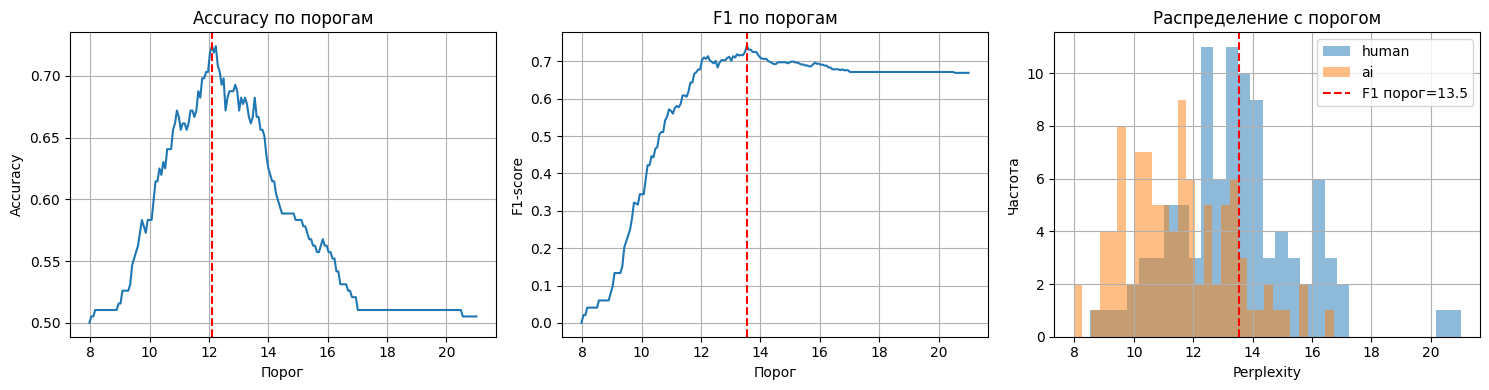

In [115]:
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score, roc_curve
import matplotlib.pyplot as plt

all_ppl = np.array(val_human_ppl + val_ai_ppl)
y_true = [0] * len(val_human_ppl) + [1] * len(val_ai_ppl)

thresholds = np.linspace(min(all_ppl), max(all_ppl), 200)

best_acc = 0
best_thresh_acc = None
acc_scores = []

for thresh in thresholds:
    y_pred = [1 if ppl < thresh else 0 for ppl in all_ppl]
    acc = accuracy_score(y_true, y_pred)
    acc_scores.append(acc)
    if acc > best_acc:
        best_acc = acc
        best_thresh_acc = thresh

best_f1 = 0
best_thresh_f1 = None
f1_scores = []

for thresh in thresholds:
    y_pred = [1 if ppl < thresh else 0 for ppl in all_ppl]
    f1 = f1_score(y_true, y_pred)
    f1_scores.append(f1)
    if f1 > best_f1:
        best_f1 = f1
        best_thresh_f1 = thresh

y_score = -all_ppl
val_auc = roc_auc_score(y_true, y_score)
fpr, tpr, roc_thresholds = roc_curve(y_true, y_score)
youden = tpr - fpr
best_idx = np.argmax(youden)
best_thresh_youden = -roc_thresholds[best_idx]
best_youden = youden[best_idx]

print(f"Accuracy порог: {best_thresh_acc:.2f} (acc={best_acc:.4f})")
print(f"F1 порог:       {best_thresh_f1:.2f} (f1={best_f1:.4f})")
print(f"AUC порог:   {best_thresh_youden:.2f} (auc={val_auc:.4f})")

# Визуализация
plt.figure(figsize=(15, 4))

plt.subplot(1, 3, 1)
plt.plot(thresholds, acc_scores)
plt.axvline(best_thresh_acc, color='red', linestyle='--')
plt.xlabel('Порог')
plt.ylabel('Accuracy')
plt.title('Accuracy по порогам')
plt.grid(True)

plt.subplot(1, 3, 2)
plt.plot(thresholds, f1_scores)
plt.axvline(best_thresh_f1, color='red', linestyle='--')
plt.xlabel('Порог')
plt.ylabel('F1-score')
plt.title('F1 по порогам')
plt.grid(True)

plt.subplot(1, 3, 3)
plt.hist(val_human_ppl, bins=30, alpha=0.5, label='human')
plt.hist(val_ai_ppl, bins=30, alpha=0.5, label='ai')
plt.axvline(best_thresh_f1, color='red', linestyle='--', label=f'F1 порог={best_thresh_f1:.1f}')
plt.xlabel('Perplexity')
plt.ylabel('Частота')
plt.title('Распределение с порогом')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

In [129]:
import json
import os
import random
import re
import numpy as np

def clean_text(text):
    """Заменяем переносы строк и табуляции на пробелы"""
    if isinstance(text, str):
        text = re.sub(r'\n|\r|\t', ' ', text)
        text = re.sub(r'\s+', ' ', text)
        return text.strip()
    return text

def load_json_texts(filepath, source_type):
    """
    Загружает тексты из JSON файла по значению поля 'source'
    source_type: 'human', 'ai', 'ai+rew' (paraphrased)
    """
    with open(filepath, 'r', encoding='utf-8') as f:
        data = json.load(f)
    
    texts = []
    for item in data:
        if item.get('source') == source_type:
            text = clean_text(item.get('text', ''))
            if len(text.split()) >= 50:
                texts.append(text)
    return texts

# Параметры второго файла (другой домен)
base_path = 'ru_hard_dataset'
domain2 = 'scientific_texts'  # или 'scientific_texts', 'long_sc' и т.д.

# Загружаем human и ai из второго домена
human_file2 = os.path.join(base_path, domain2, 'orig_scientific.json')
ai_file2 = os.path.join(base_path, domain2, 'generated_scientific.json')

human_texts2 = load_json_texts(human_file2, 'human')
ai_texts2 = load_json_texts(ai_file2, 'ai')

print(f"Второй файл ({domain2}) - после фильтрации по длине:")
print(f"  Human: {len(human_texts2)} текстов")
print(f"  AI: {len(ai_texts2)} текстов")

# Берем сбалансированную выборку такого же размера как валидационная
n_samples = val_size

if len(human_texts2) < n_samples:
    print(f"\n⚠️ Внимание: human текстов меньше ({len(human_texts2)}), берем все")
    n_samples = len(human_texts2)

if len(ai_texts2) < n_samples:
    print(f"\n⚠️ Внимание: ai текстов меньше ({len(ai_texts2)}), берем все")
    n_samples = min(n_samples, len(ai_texts2))

print(f"\nБерем {n_samples} текстов каждого класса")

# Случайная выборка
test_human = random.sample(human_texts2, n_samples) if len(human_texts2) >= n_samples else human_texts2
test_ai = random.sample(ai_texts2, n_samples) if len(ai_texts2) >= n_samples else ai_texts2

print(f"\nТестовая выборка:")
print(f"  Human: {len(test_human)} текстов")
print(f"  AI: {len(test_ai)} текстов")

# Сохраняем тестовые файлы
with open('test_human.txt', 'w', encoding='utf-8') as f:
    for text in test_human:
        f.write(clean_text(text) + '\n')

with open('test_ai.txt', 'w', encoding='utf-8') as f:
    for text in test_ai:
        f.write(clean_text(text) + '\n')

print("\nСохранено:")
print(f"  test_human.txt: {len(test_human)} текстов")
print(f"  test_ai.txt: {len(test_ai)} текстов")

Второй файл (scientific_texts) - после фильтрации по длине:
  Human: 479 текстов
  AI: 479 текстов

Берем 96 текстов каждого класса

Тестовая выборка:
  Human: 96 текстов
  AI: 96 текстов

Сохранено:
  test_human.txt: 96 текстов
  test_ai.txt: 96 текстов


In [130]:
test_human_ppl = [get_perplexity(model, text) for text in test_human]
test_human_ppl = [x for x in test_human_ppl if x is not None]

test_ai_ppl = [get_perplexity(model, text) for text in test_ai]
test_ai_ppl = [x for x in test_ai_ppl if x is not None]

print(f"\nТестовая перплексия:")
print(f"  Human среднее: {np.mean(test_human_ppl):.2f}")
print(f"  AI среднее: {np.mean(test_ai_ppl):.2f}")

test_all_ppl = np.array(test_human_ppl + test_ai_ppl)
y_test_true = [0] * len(test_human_ppl) + [1] * len(test_ai_ppl)

final_threshold = best_thresh_acc
y_test_pred = [1 if ppl < final_threshold else 0 for ppl in test_all_ppl]

print(f"Используем порог по Acc: {final_threshold:.2f}")
print(f"Предсказано machine: {sum(y_test_pred)} из {len(y_test_pred)}")


Тестовая перплексия:
  Human среднее: 17.46
  AI среднее: 14.52
Используем порог по Acc: 12.10
Предсказано machine: 11 из 192


In [95]:
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score, confusion_matrix

test_acc = accuracy_score(y_test_true, y_test_pred)
test_f1 = f1_score(y_test_true, y_test_pred)
test_auc = roc_auc_score(y_test_true, -test_all_ppl)

print(f"Accuracy:  {test_acc:.4f}")
print(f"F1-score:  {test_f1:.4f}")
print(f"ROC-AUC:   {test_auc:.4f}")

cm = confusion_matrix(y_test_true, y_test_pred)
print("\nМатрица ошибок:")
print("           Pred human  Pred machine")
print(f"Actual human    {cm[0,0]:5d}      {cm[0,1]:5d}")
print(f"Actual machine  {cm[1,0]:5d}      {cm[1,1]:5d}")

Accuracy:  0.7292
F1-score:  0.7045
ROC-AUC:   0.8288

Матрица ошибок:
           Pred human  Pred machine
Actual human       78         18
Actual machine     34         62


In [96]:
print(f"{'Метрика':<12} {'Валидация':>10} {'Тест':>10} {'Разница':>10}")
print("-"*50)
print(f"{'F1-score':<12} {best_f1:>10.4f} {test_f1:>10.4f} {test_f1 - best_f1:>+10.4f}")
print(f"{'Accuracy':<12} {best_acc:>10.4f} {test_acc:>10.4f} {test_acc - best_acc:>+10.4f}")
print(f"{'ROC-AUC':<12} {val_auc:>10.4f} {test_auc:>10.4f} {test_auc - val_auc:>+10.4f}")

Метрика       Валидация       Тест    Разница
--------------------------------------------------
F1-score         0.8177     0.7045    -0.1131
Accuracy         0.8281     0.7292    -0.0990
ROC-AUC          0.8845     0.8288    -0.0558


/tmp/ipykernel_26/810686892.py:27: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = plt.boxplot(data_to_plot, labels=['human', 'ai'], patch_artist=True)


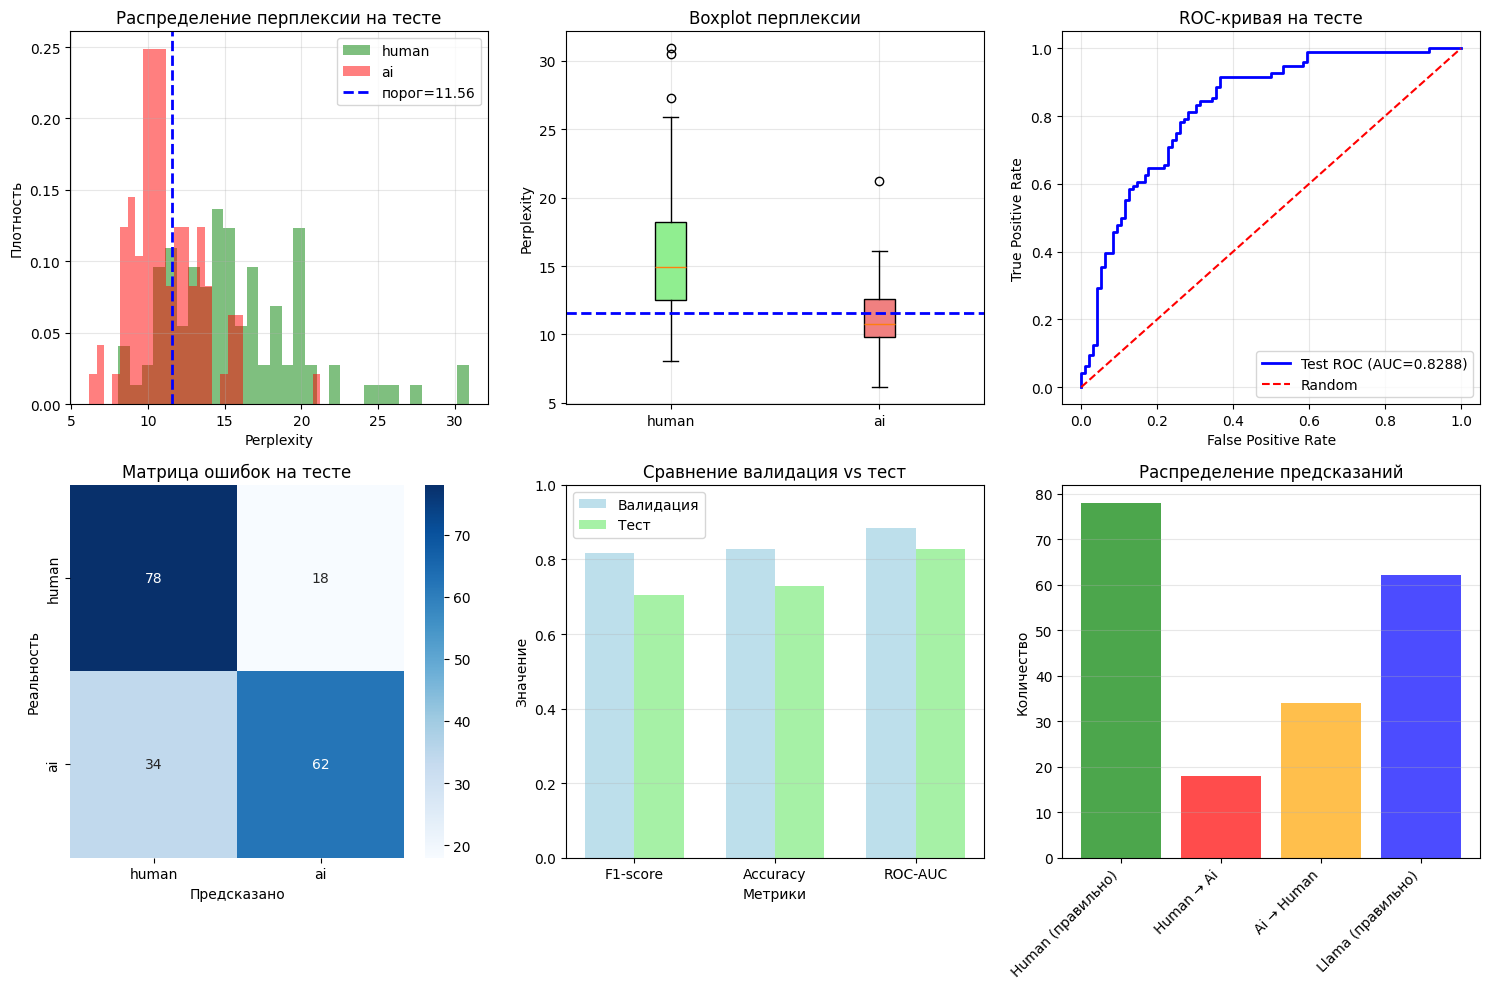


Итоговые метрики на тесте (порог F1=11.56):
  Accuracy: 0.7292
  F1-score: 0.7045
  ROC-AUC:  0.8288


In [98]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import roc_curve, confusion_matrix
import seaborn as sns

test_machine_ppl = test_ai_ppl
y_test_true = [0]*len(test_human_ppl) + [1]*len(test_machine_ppl)
y_test_score = -np.array(test_human_ppl + test_machine_ppl)

plt.figure(figsize=(15, 10))

# 1. Распределение перплексии на тесте
plt.subplot(2, 3, 1)
plt.hist(test_human_ppl, bins=30, alpha=0.5, label='human', density=True, color='green')
plt.hist(test_machine_ppl, bins=30, alpha=0.5, label='ai', density=True, color='red')
plt.axvline(x=final_threshold, color='blue', linestyle='--', linewidth=2, 
            label=f'порог={final_threshold:.2f}')
plt.xlabel('Perplexity')
plt.ylabel('Плотность')
plt.title('Распределение перплексии на тесте')
plt.legend()
plt.grid(True, alpha=0.3)

# 2. Boxplot
plt.subplot(2, 3, 2)
data_to_plot = [test_human_ppl, test_machine_ppl]
bp = plt.boxplot(data_to_plot, labels=['human', 'ai'], patch_artist=True)
bp['boxes'][0].set_facecolor('lightgreen')
bp['boxes'][1].set_facecolor('lightcoral')
plt.axhline(y=final_threshold, color='blue', linestyle='--', linewidth=2)
plt.ylabel('Perplexity')
plt.title('Boxplot перплексии')
plt.grid(True, alpha=0.3)

# 3. ROC-кривая
plt.subplot(2, 3, 3)
fpr_test, tpr_test, _ = roc_curve(y_test_true, y_test_score)
plt.plot(fpr_test, tpr_test, 'b-', linewidth=2, label=f'Test ROC (AUC={test_auc:.4f})')
plt.plot([0,1], [0,1], 'r--', label='Random')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC-кривая на тесте')
plt.legend()
plt.grid(True, alpha=0.3)

# 4. Матрица ошибок
plt.subplot(2, 3, 4)
cm = confusion_matrix(y_test_true, y_test_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['human', 'ai'], 
            yticklabels=['human', 'ai'])
plt.xlabel('Предсказано')
plt.ylabel('Реальность')
plt.title('Матрица ошибок на тесте')

# 5. Сравнение метрик валидация vs тест
plt.subplot(2, 3, 5)
metrics = ['F1-score', 'Accuracy', 'ROC-AUC']
val_values = [best_f1, best_acc, val_auc]
test_values = [test_f1, test_acc, test_auc]
x = np.arange(len(metrics))
width = 0.35
plt.bar(x - width/2, val_values, width, label='Валидация', color='lightblue', alpha=0.8)
plt.bar(x + width/2, test_values, width, label='Тест', color='lightgreen', alpha=0.8)
plt.xlabel('Метрики')
plt.ylabel('Значение')
plt.title('Сравнение валидация vs тест')
plt.xticks(x, metrics)
plt.legend()
plt.grid(True, alpha=0.3, axis='y')
plt.ylim([0, 1])

# 6. Предсказания по классам
plt.subplot(2, 3, 6)
labels = ['Human (правильно)', 'Human → Ai', 'Ai → Human', 'Llama (правильно)']
values = [cm[0,0], cm[0,1], cm[1,0], cm[1,1]]
colors = ['green', 'red', 'orange', 'blue']
plt.bar(labels, values, color=colors, alpha=0.7)
plt.ylabel('Количество')
plt.title('Распределение предсказаний')
plt.xticks(rotation=45, ha='right')
plt.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

print(f"\nИтоговые метрики на тесте (порог F1={final_threshold:.2f}):")
print(f"  Accuracy: {test_acc:.4f}")
print(f"  F1-score: {test_f1:.4f}")
print(f"  ROC-AUC:  {test_auc:.4f}")